# Tire-Patch-Wear Transformer

This repo's own combination, not a reproduction of a published paper: spatial self-attention over tire contact-patch positions + real brush-model mechanics (Pacejka, *Tire and Vehicle Dynamics*, 2012) + Archard's wear law (Archard, 1953). See `model.py`'s module docstring for the full honesty note, including the credit to the sibling `tire_physics_nn` project whose real physics this re-derives.

No public tire-contact-patch-wear dataset exists, so training data is physics-simulated -- not arbitrary: the simulator below produces a genuine, non-uniform wear pattern (concentrated near the trailing edge, where the brush model's adhesion region first gives way to sliding).

In [1]:
import sys
sys.path.insert(0, '../..')
sys.path.insert(0, '.')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformer_playground.device import resolve_device
from model import TirePatchWearTransformer, simulate_wear_trajectory

device = resolve_device('auto')
print('device:', device)

device: cpu


/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
from example import build_dataset

n_elements = 32
p_train, w_train, y_train = build_dataset(40, 60, n_elements, seed_offset=0)
p_test, w_test, y_test = build_dataset(10, 60, n_elements, seed_offset=10_000)
p_mean, p_std = p_train.mean(), p_train.std()
p_train_n, p_test_n = (p_train - p_mean) / p_std, (p_test - p_mean) / p_std
print(p_train.shape, p_test.shape)

# Look at one full trajectory's ground-truth wear pattern -- non-uniform
# by construction (real brush-model adhesion/sliding split), not noise.
one_traj = simulate_wear_trajectory(n_elements=n_elements, n_revolutions=60, seed=0)
print('final wear per patch position:', one_traj['wear_cumulative'][-1].round(decimals=2).tolist())

torch.Size([2400, 32]) torch.Size([600, 32])
final wear per patch position: [41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 41.59000015258789, 43.43000030517578, 49.66999816894531, 58.540000915527344, 68.16000366210938, 68.97000122070312, 61.95000076293945, 53.599998474121094, 45.4900016784668]


In [3]:
model = TirePatchWearTransformer(n_elements=n_elements).to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)

def predicted_increment(p, w):
    return F.softplus(model(p, w))  # structurally >= 0, mirrors tire_physics_nn's wear_rate invariant

batch_size = 64
n = p_train_n.shape[0]
history = {'train_mse': [], 'test_mse': []}
for epoch in range(30):
    perm = torch.randperm(n)
    total, nb = 0.0, 0
    for i in range(0, n, batch_size):
        idx = perm[i:i + batch_size]
        opt.zero_grad()
        pred = predicted_increment(p_train_n[idx].to(device), w_train[idx].to(device))
        loss = nn.functional.mse_loss(pred, y_train[idx].to(device))
        loss.backward()
        opt.step()
        total += loss.item(); nb += 1
    with torch.no_grad():
        test_loss = nn.functional.mse_loss(predicted_increment(p_test_n.to(device), w_test.to(device)), y_test.to(device)).item()
    history['train_mse'].append(total / nb)
    history['test_mse'].append(test_loss)
print('final test_mse:', history['test_mse'][-1])

final test_mse: 0.027569007128477097


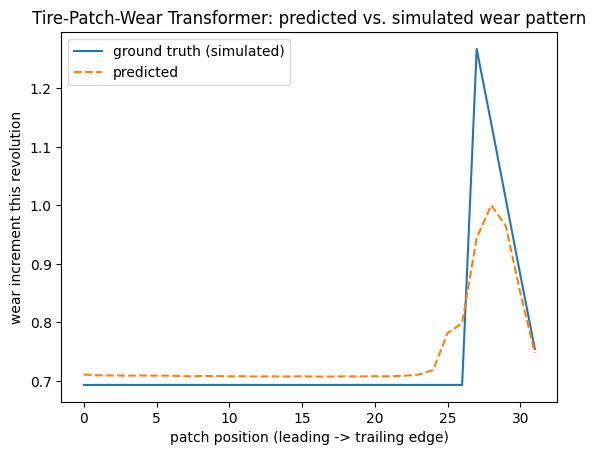

In [4]:
# Ground truth vs. predicted wear-increment pattern across the patch, one
# held-out revolution -- the real evidence this model learned the real,
# non-uniform (adhesion-vs-sliding) shape, not just a flat average.
model.eval()
with torch.no_grad():
    idx = 45  # a mid-trajectory revolution in the test set
    pred = predicted_increment(p_test_n[idx:idx+1].to(device), w_test[idx:idx+1].to(device))[0].cpu()
true = y_test[idx]
plt.plot(true, label='ground truth (simulated)')
plt.plot(pred, label='predicted', linestyle='--')
plt.xlabel('patch position (leading -> trailing edge)')
plt.ylabel('wear increment this revolution')
plt.legend()
plt.title('Tire-Patch-Wear Transformer: predicted vs. simulated wear pattern')
plt.show()